In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importe le csv des Tenracs et calcule leur nombre décroissant en avance + fusionne les Masc avec Fem
bd = pd.read_csv('./tenrac.csv')
fusion = {'AFFILIEE':'AFFILIE', 'SYMPATISANTE':'SYMPATISANT', 'ADHERANTE':'ADHERANT',
          'DAME':'CHEVALIER', 'HAUTE DAME':'GRAND CHEVALIER',
          'COMMANDERESSE':'COMMANDEUR', 'GRANDE-CROIX':'GRAND CROIX'}

nbGrade = (bd['typeGrade ']
             .str.strip() # Nettoie les espaces
             .map(lambda x: fusion.get(x, x)) # Fusionne
             .value_counts()
             .sort_values(ascending=False))

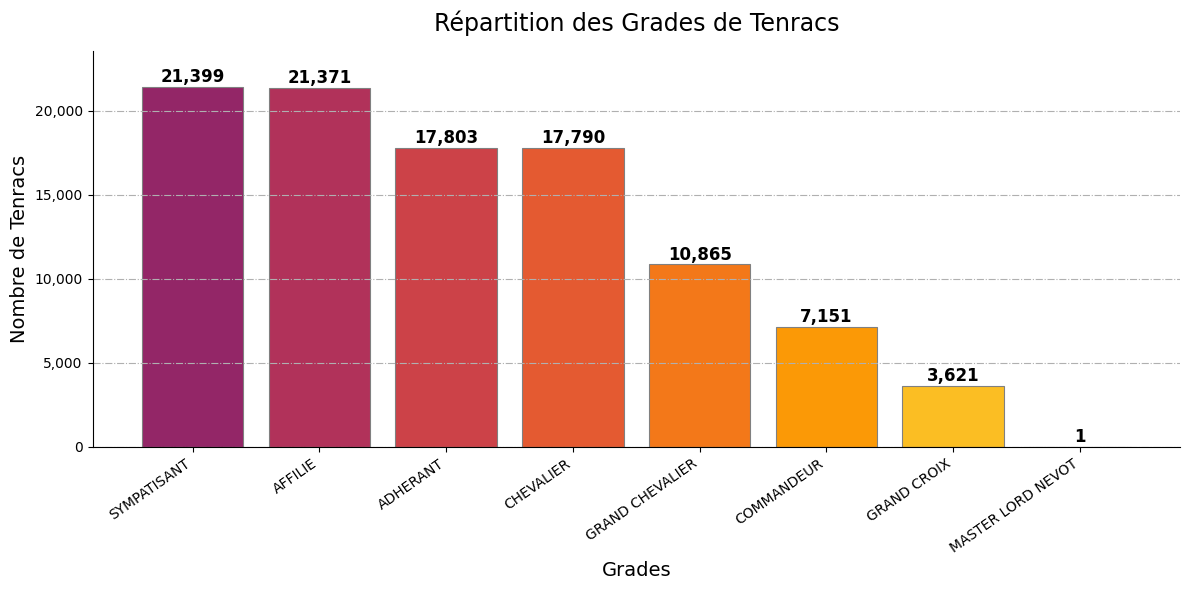

In [4]:
# Génère des couleurs uniformément depuis la palette "inferno"
couleur = plt.cm.inferno(np.linspace(0.4, 0.85, len(nbGrade)))

# Crée la figure et les axes
fig, ax = plt.subplots(figsize=(12, 6))
nbGrade['MASTER LORD NEVOT'] = 1
# Dessine les barres : index = noms des grades, values = effectifs
bars = ax.bar(nbGrade.index, nbGrade.values, color=couleur, edgecolor='grey', linewidth=0.8)

# Pour chaque barre, affiche le chiffre exact au-dessus
for bar, val in zip(bars, nbGrade.values):
    ax.text(bar.get_x() + bar.get_width() / 2,  # centré horizontalement
            bar.get_height() + 50,                     # positionné en haut de la barre + un peu plus
            f'{val:,}',                           # séparateur milliers
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Répartition des Grades de Tenracs', fontsize=17, pad=15)
ax.set_xlabel('Grades', fontsize=14)
ax.set_ylabel('Nombre de Tenracs', fontsize=14)
# Ajoute de l'espace au-dessus de la barre la plus haute
ax.set_ylim(0, nbGrade.max() * 1.1)

# Incline les grades à 35° alignées à droite
ax.tick_params(axis='x', rotation=35)
plt.xticks(ha='right')

# Formate l'axe Y avec des virgules
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Supprime les bordures du haut et de droite, plus joli
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajoute une grille en pointillés
ax.grid(axis='y', linestyle='-.')

# Ajuste les marges
plt.tight_layout()

# Commande pour télécharger le png
# plt.savefig('DiagrammeGrade.png', dpi=1000, bbox_inches='tight')

plt.show()